In [5]:
import pandas as pd
# Importar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [6]:
df = pd.read_csv('bank_data.csv', sep=";")

In [7]:

print(df.head())


print(df.info())


print(df.describe())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #

In [8]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [9]:
print(df.duplicated().value_counts())

False    45211
Name: count, dtype: int64


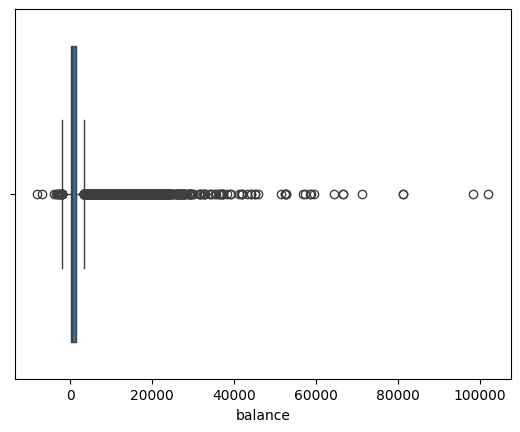

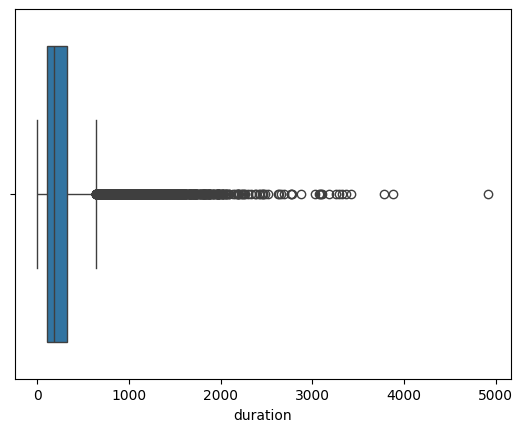

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de distribución para detectar posibles outliers en la columna balance
sns.boxplot(x=df['balance'])
plt.show()

# Gráfico de distribución para la duración de la llamada
sns.boxplot(x=df['duration'])
plt.show()


C:\Users\57301\AppData\Local\Temp\ipykernel_19780\1713754198.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_counts = df.groupby(['age_group', 'y']).size().unstack(fill_value=0)


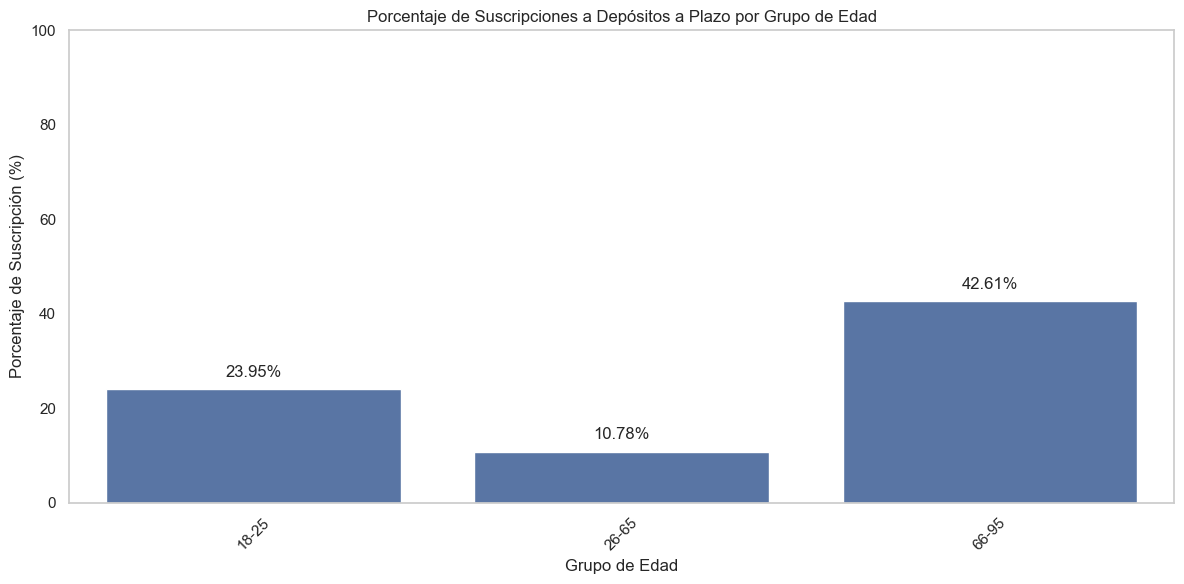

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Convertir la variable objetivo a numérica
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Crear una nueva columna para agrupar por rangos de edad
bins = [18, 26, 66, 96]
labels = ['18-25', '26-65', '66-95']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Calcular el conteo de suscripciones por grupo de edad
age_counts = df.groupby(['age_group', 'y']).size().unstack(fill_value=0)

# Calcular el porcentaje de suscripciones
age_counts['Total'] = age_counts.sum(axis=1)
age_counts['Suscripción (%)'] = (age_counts[1] / age_counts['Total']) * 100

# Crear la gráfica de barras para porcentajes
plt.figure(figsize=(12, 6))
sns.barplot(x=age_counts.index, y=age_counts['Suscripción (%)'])

plt.title('Porcentaje de Suscripciones a Depósitos a Plazo por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Porcentaje de Suscripción (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45)

# Añadir etiquetas de porcentaje encima de las barras
for index, value in enumerate(age_counts['Suscripción (%)']):
    plt.text(index, value + 2, f"{value:.2f}%", ha='center', va='bottom')

plt.grid(axis='y')
plt.tight_layout()
plt.show()


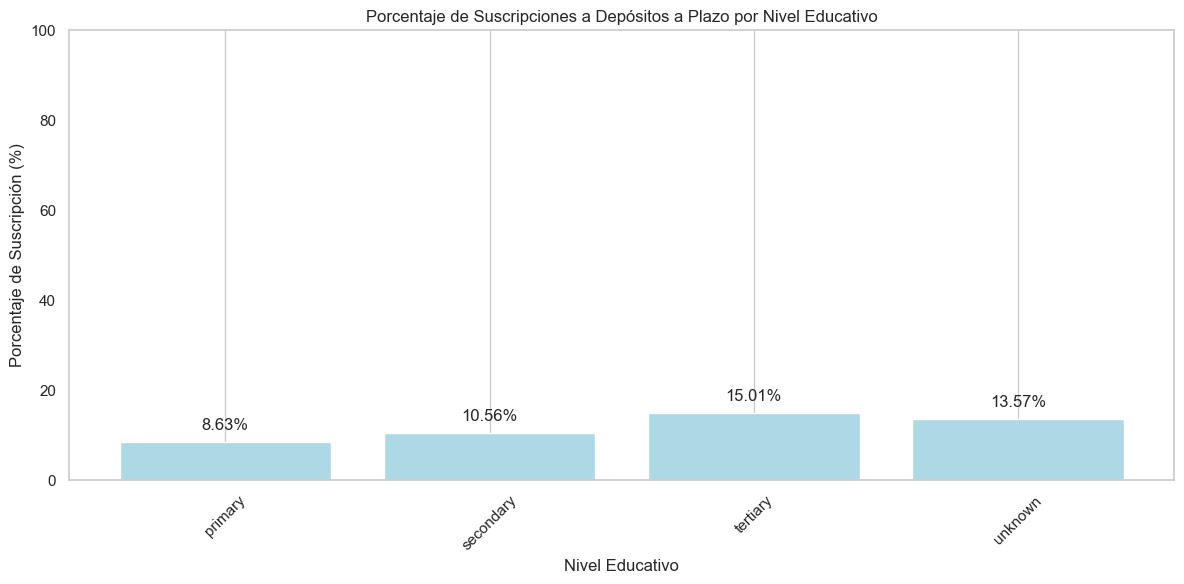

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Convertir la variable objetivo a numérica
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Calcular el conteo de suscripciones por nivel educativo
education_counts = df.groupby(['education', 'y']).size().unstack(fill_value=0)

# Calcular el porcentaje de suscripciones
education_counts['Total'] = education_counts.sum(axis=1)
education_counts['Suscripción (%)'] = (education_counts[1] / education_counts['Total']) * 100

# Crear la gráfica de barras
plt.figure(figsize=(12, 6))
plt.bar(education_counts.index, education_counts['Suscripción (%)'], color='lightblue')

plt.title('Porcentaje de Suscripciones a Depósitos a Plazo por Nivel Educativo')
plt.xlabel('Nivel Educativo')
plt.ylabel('Porcentaje de Suscripción (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.grid(axis='y')

# Añadir etiquetas de porcentaje encima de las barras
for index, value in enumerate(education_counts['Suscripción (%)']):
    plt.text(index, value + 2, f"{value:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()


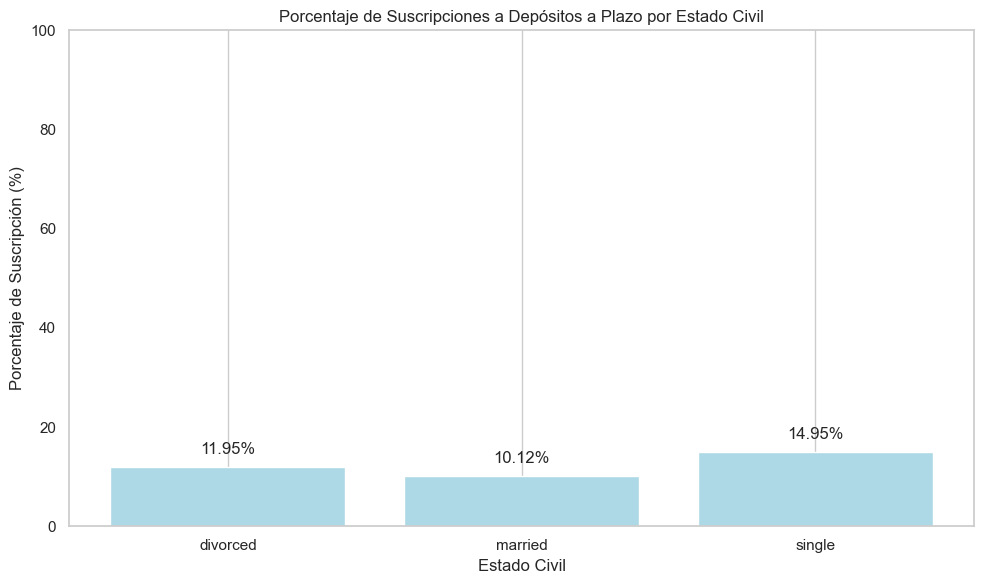

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv('bank_data.csv', sep=';')

# Convertir la variable objetivo a numérica
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Calcular el conteo de suscripciones por estado civil
marital_counts = df.groupby('marital')['y'].value_counts().unstack(fill_value=0)

# Calcular el porcentaje de suscripciones
marital_counts['Total'] = marital_counts.sum(axis=1)
marital_counts['Suscripción (%)'] = (marital_counts[1] / marital_counts['Total']) * 100

# Crear la gráfica de barras
plt.figure(figsize=(10, 6))
plt.bar(marital_counts.index, marital_counts['Suscripción (%)'], color='lightblue')

plt.title('Porcentaje de Suscripciones a Depósitos a Plazo por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Porcentaje de Suscripción (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.grid(axis='y')

# Añadir etiquetas de porcentaje encima de las barras
for index, value in enumerate(marital_counts['Suscripción (%)']):
    plt.text(index, value + 2, f"{value:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()
